This code was inspired by the Neural Network websites I cited, but also generated with Gemini. I went through and manually changed values, ensuring I understood what the code was doing.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler # Fixed: Changed RandomUserSampler to RandomUnderSampler
from imblearn.over_sampling import SMOTE

# 1. Load the dataset
df = pd.read_csv("predicts_nn.csv")

# 2. Process 'health_status' to ensure it's numeric and handle non-numeric/missing values
# Convert to numeric, coercing non-numeric strings to NaN
df['health_status_numeric'] = pd.to_numeric(df['health_status'], errors='coerce')

# Drop rows where 'health_status_numeric' is NaN (these were original NaNs or non-numeric strings)
df_cleaned = df.dropna(subset=['health_status_numeric'])

# Separate features (X) and target/label (y) from the cleaned DataFrame
# Drop the original 'health_status' column and the temporary 'health_status_numeric' from X
# The other columns listed in the previous error (e.g., 'class', 'kingdom') are not present in df_cleaned anymore
X = df_cleaned.drop(columns=["health_status", "health_status_numeric"])
y = df_cleaned["health_status_numeric"]

# Check the number of samples after cleaning
print(f"Shape of X after cleaning: {X.shape}")
print(f"Shape of y after cleaning: {y.shape}")
print(f"Value counts of y after cleaning:\n{y.value_counts()}")
print(f"Data type of y after cleaning: {y.dtype}")

# 3. Ensure your target variable is treated as categorical (classes 1, 2, 3) and is integer type
y = y.astype(int)
# Subtract 1 from the target variable to make it 0-indexed for sparse_categorical_crossentropy
y = y - 1
print(f"Data type of y after final conversion: {y.dtype}")
print(f"Value counts of y after 0-indexing:\n{y.value_counts()}")

# 4. Split into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(pd.Series(y_train_resampled).value_counts())

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X after cleaning: (715610, 43)
Shape of y after cleaning: (715610,)
Value counts of y after cleaning:
health_status_numeric
1    497108
3    109781
2    108721
Name: count, dtype: int64
Data type of y after cleaning: int64
Data type of y after final conversion: int64
Value counts of y after 0-indexing:
health_status_numeric
0    497108
2    109781
1    108721
Name: count, dtype: int64
health_status_numeric
0    86977
1    86977
2    86977
Name: count, dtype: int64
Shape of X_train: (572488, 43)
Shape of y_train: (572488,)
Shape of X_test: (143122, 43)
Shape of y_test: (143122,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify the remaining object columns in X_train
object_cols = X_train.select_dtypes(include='object').columns

print(f"Object columns to encode: {list(object_cols)}")

# Apply Label Encoding to each object column in both X_train and X_test
for col in object_cols:
    le = LabelEncoder()

    # Ensure all values in the column are treated as strings before fitting the encoder
    train_col_str = X_train[col].astype(str)
    test_col_str = X_test[col].astype(str)

    # First, get all unique categories from both train and test to fit the encoder
    all_categories = pd.concat([train_col_str, test_col_str], axis=0).unique()
    le.fit(all_categories)

    X_train[col] = le.transform(train_col_str)
    X_test[col] = le.transform(test_col_str)

print("\nShape of X_train after encoding:", X_train.shape)
print("Shape of X_test after encoding:", X_test.shape)

print("\nFirst 5 rows of X_train after encoding:")
display(X_train.head())

print("\nData types of X_train after encoding:")
X_train.info()

Object columns to encode: ['biome', 'country', 'realm', 'un_subregion']

Shape of X_train after encoding: (572488, 43)
Shape of X_test after encoding: (143122, 43)

First 5 rows of X_train after encoding:


,diversity_metric_is_effort_sensitive,diversity_metric_is_suitable_for_chao,effort_corrected_measurement,is_present,predominant_land_use_cropland,predominant_land_use_intermediate_secondary_vegetation,predominant_land_use_mature_secondary_vegetation,predominant_land_use_pasture,predominant_land_use_plantation_forest,predominant_land_use_primary_vegetation,...,sampling_method_sweep_net,sampling_method_systematic_searching,sampling_method_transect,sampling_method_trap_nests,sampling_method_various,sampling_method_visual_encounter_survey,biome,country,realm,un_subregion
395853,1,1,-0.241578,0,0,0,0,0,0,0,...,0,0,0,0,0,0,11,21,0,3
362279,1,1,-0.241578,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,20,5,4
112123,1,1,-0.241578,0,0,0,0,0,0,1,...,0,0,0,0,0,0,7,28,5,5
430498,1,1,-0.241578,0,0,0,0,0,0,1,...,0,0,0,0,0,0,12,17,2,11
472776,1,1,0.880978,1,0,0,0,1,0,0,...,0,0,0,0,0,0,6,35,5,7



Data types of X_train after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 572488 entries, 395853 to 303594
Data columns (total 43 columns):
 #   Column                                                       Non-Null Count   Dtype  
---  ------                                                       --------------   -----  
 0   diversity_metric_is_effort_sensitive                         572488 non-null  int64  
 1   diversity_metric_is_suitable_for_chao                        572488 non-null  int64  
 2   effort_corrected_measurement                                 572488 non-null  float64
 3   is_present                                                   572488 non-null  int64  
 4   predominant_land_use_cropland                                572488 non-null  int64  
 5   predominant_land_use_intermediate_secondary_vegetation       572488 non-null  int64  
 6   predominant_land_use_mature_secondary_vegetation             572488 non-null  int64  
 7   predominant_land_use_pastu

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Identify categorical columns that will use embedding layers
embedding_features = ['country', 'realm', 'un_subregion', 'biome']

# Calculate vocabulary size (number of unique categories) and embedding dimension for each feature
embedding_dims = {}
for col in embedding_features:
    vocab_size = int(pd.concat([X_train[col], X_test[col]], axis=0).nunique())
    # A common heuristic for embedding dimension is min(50, vocab_size // 2)
    embed_dim = min(50, vocab_size // 2)
    embedding_dims[col] = {'vocab_size': vocab_size, 'embed_dim': embed_dim}
    print(f"Feature '{col}': Vocabulary Size = {vocab_size}, Embedding Dimension = {embed_dim}")

# Separate numerical and categorical features
# Ensure 'biome' is treated as a numerical feature if it's already encoded as an int64
numerical_features = [col for col in X_train.columns if col not in embedding_features]

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")

Feature 'country': Vocabulary Size = 40, Embedding Dimension = 20
Feature 'realm': Vocabulary Size = 6, Embedding Dimension = 3
Feature 'un_subregion': Vocabulary Size = 16, Embedding Dimension = 8
Feature 'biome': Vocabulary Size = 13, Embedding Dimension = 6

Numerical features (39): ['diversity_metric_is_effort_sensitive', 'diversity_metric_is_suitable_for_chao', 'effort_corrected_measurement', 'is_present', 'predominant_land_use_cropland', 'predominant_land_use_intermediate_secondary_vegetation', 'predominant_land_use_mature_secondary_vegetation', 'predominant_land_use_pasture', 'predominant_land_use_plantation_forest', 'predominant_land_use_primary_vegetation', 'predominant_land_use_secondary_vegetation_indeterminate_age', 'predominant_land_use_urban', 'predominant_land_use_young_secondary_vegetation', 'use_intensity_intense_use', 'use_intensity_light_use', 'use_intensity_minimal_use', 'sampling_method_baited_pit_fall_traps', 'sampling_method_baited_traps', 'sampling_method_fixed_

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.utils import class_weight # Import class_weight
import pandas as pd # Import pandas for nunique

# Identify categorical columns that will use embedding layers
embedding_features = ['country', 'realm', 'un_subregion', 'biome']

# Calculate vocabulary size (number of unique categories) and embedding dimension for each feature
embedding_dims = {}
for col in embedding_features:
    vocab_size = int(pd.concat([X_train[col], X_test[col]], axis=0).nunique()) + 1 # +1 for potential 0-indexing issues or padding
    # A common heuristic for embedding dimension is min(50, vocab_size // 2)
    embed_dim = min(50, vocab_size // 2)
    embedding_dims[col] = {'vocab_size': vocab_size, 'embed_dim': embed_dim}
    print(f"Feature '{col}': Vocabulary Size = {vocab_size}, Embedding Dimension = {embed_dim}")

# Separate numerical and categorical features
numerical_features = [col for col in X_train.columns if col not in embedding_features]

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")

def build_model(numerical_features, embedding_dims, num_classes):
    # Input layers for numerical features
    numerical_input = keras.Input(shape=(len(numerical_features),), name='numerical_input')

    # Input layers and embedding layers for categorical features
    embedding_outputs = []
    categorical_inputs_list = [] # List to store categorical input layers

    for col, dims in embedding_dims.items():
        vocab_size = dims['vocab_size']
        embed_dim = dims['embed_dim']

        categorical_input = keras.Input(shape=(1,), name=f'{col}_input')
        categorical_inputs_list.append(categorical_input) # Store the input layer

        embedding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, name=f'{col}_embedding')(categorical_input)
        flatten_embedding = layers.Flatten(name=f'{col}_flatten')(embedding)
        embedding_outputs.append(flatten_embedding)

    if embedding_outputs:
        concatenated_inputs = layers.concatenate([numerical_input] + embedding_outputs, name='concatenated_features')
    else:
        concatenated_inputs = numerical_input

    x = layers.Dense(256, activation='elu')(concatenated_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='elu')(x)
    x = layers.Dropout(0.2)(x)

    output_layer = layers.Dense(num_classes, activation='softmax', name='output')(x)

    # Define the model, reusing the categorical_input layers stored in categorical_inputs_list
    all_inputs = [numerical_input] + categorical_inputs_list
    model = keras.Model(inputs=all_inputs, outputs=output_layer)
    return model

# Determine the number of classes for the target variable based on unique values in y_train
num_classes = len(np.unique(y_train))
print(f"Number of classes determined from y_train: {num_classes}")

# Manually set class weights: Start with 1 for all classes, then adjust as needed
# Since y_train_resampled is balanced, compute_class_weight('balanced') on it would yield 1s anyway.
# We can directly initialize the dictionary.
class_weight_dict = {i: 1.0 for i in range(num_classes)}
# Manually adjust weight for class 2 to penalize missing it more
class_weight_dict[2] = class_weight_dict[2] * 4 # Increase weight for class 2 by 50%
print(f"Calculated class weights: {class_weight_dict}")

# Build the model
model = build_model(numerical_features, embedding_dims, num_classes=int(num_classes))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Feature 'country': Vocabulary Size = 41, Embedding Dimension = 20
Feature 'realm': Vocabulary Size = 7, Embedding Dimension = 3
Feature 'un_subregion': Vocabulary Size = 17, Embedding Dimension = 8
Feature 'biome': Vocabulary Size = 14, Embedding Dimension = 7

Numerical features (39): ['diversity_metric_is_effort_sensitive', 'diversity_metric_is_suitable_for_chao', 'effort_corrected_measurement', 'is_present', 'predominant_land_use_cropland', 'predominant_land_use_intermediate_secondary_vegetation', 'predominant_land_use_mature_secondary_vegetation', 'predominant_land_use_pasture', 'predominant_land_use_plantation_forest', 'predominant_land_use_primary_vegetation', 'predominant_land_use_secondary_vegetation_indeterminate_age', 'predominant_land_use_urban', 'predominant_land_use_young_secondary_vegetation', 'use_intensity_intense_use', 'use_intensity_light_use', 'use_intensity_minimal_use', 'sampling_method_baited_pit_fall_traps', 'sampling_method_baited_traps', 'sampling_method_fixed_

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ country_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ realm_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ un_subregion_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ biome_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_embedding   │ (None, 1, 20)     │        820 │ country_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ realm_embedding     │ (None, 1, 3)      │         21 │ realm_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ un_subregion_embed… │ (None, 1, 8)      │        136 │ un_subregion_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ biome_embedding     │ (None, 1, 7)      │         98 │ biome_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_flatten     │ (None, 20)        │          0 │ country_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ realm_flatten       │ (None, 3)         │          0 │ realm_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ un_subregion_flatt… │ (None, 8)         │          0 │ un_subregion_emb… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ biome_flatten       │ (None, 7)         │          0 │ biome_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenated_featu… │ (None, 77)        │          0 │ numerical_input[… │
│ (Concatenate)       │                   │            │ country_flatten[… │
│                     │                   │            │ realm_flatten[0]… │
│                     │                   │            │ un_subregion_fla… │
│                     │                   │            │ biome_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │     19,968 │ concatenated_fea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 63,926 (249.71 KB)

 Trainable params: 63,158 (246.71 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_numerical = X_train[numerical_features]
# Scale numerical features
scaler = StandardScaler()
X_train_numerical_scaled = scaler.fit_transform(X_train_numerical)
X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_features, index=X_train_numerical.index)

X_train_categorical_inputs = {col: X_train[col] for col in embedding_features}

# Combine numerical and categorical inputs into a dictionary for the model
# The keys must match the input layer names defined in the build_model function
model_inputs_train = {'numerical_input': X_train_numerical_scaled_df}
model_inputs_train.update({f'{col}_input': X_train_categorical_inputs[col] for col in embedding_features})

print("Prepared training inputs.")

Prepared training inputs.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,          # stop if no improvement for 10 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)

history = model.fit(
    model_inputs_train,
    y_train,
    epochs=100,           # let early stopping decide when to quit
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict, # Apply class weights here
    verbose=1
)

Epoch 1/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - accuracy: 0.7214 - loss: 0.8031 - val_accuracy: 0.6924 - val_loss: 0.4964 - learning_rate: 0.0010
Epoch 2/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.7437 - loss: 0.7380 - val_accuracy: 0.8132 - val_loss: 0.4504 - learning_rate: 0.0010
Epoch 3/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.7512 - loss: 0.7258 - val_accuracy: 0.7254 - val_loss: 0.4686 - learning_rate: 0.0010
Epoch 4/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - accuracy: 0.7537 - loss: 0.7210 - val_accuracy: 0.7062 - val_loss: 0.4868 - learning_rate: 0.0010
Epoch 5/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.7543 - loss: 0.7164 - val_accuracy: 0.6984 - val_loss: 0.5075 - learning_rate: 0.0010
Epoch 6/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.7544 - loss: 0.7140 - val_accuracy: 0.8163 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 7/100
7157/7157 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - accura

In [ ]:
X_test_numerical = X_test[numerical_features]
# Scale numerical features using the scaler fitted on training data
X_test_numerical_scaled = scaler.transform(X_test_numerical)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_features, index=X_test_numerical.index)


X_test_categorical_inputs = {col: X_test[col] for col in embedding_features}

# Combine numerical and categorical inputs into a dictionary for the model
model_inputs_test = {'numerical_input': X_test_numerical_scaled_df}
model_inputs_test.update({f'{col}_input': X_test_categorical_inputs[col] for col in embedding_features})

print("Prepared test inputs.")

Prepared test inputs.


4473/4473 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Predictions made on test data.


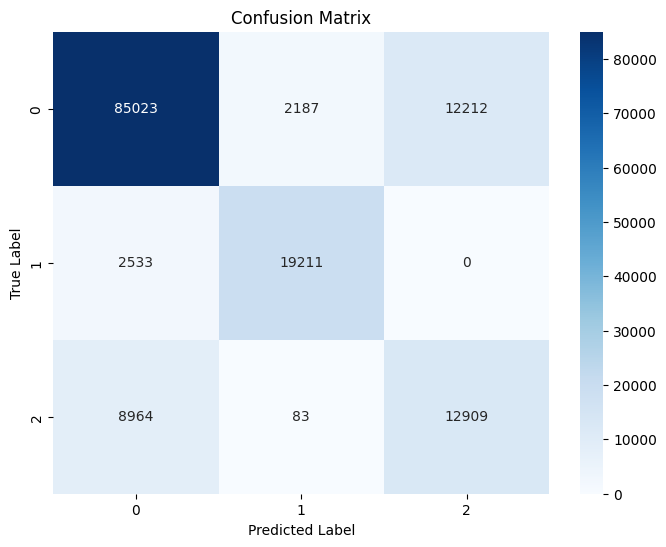


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     99422
           1       0.89      0.88      0.89     21744
           2       0.51      0.59      0.55     21956

    accuracy                           0.82    143122
   macro avg       0.76      0.78      0.77    143122
weighted avg       0.83      0.82      0.82    143122



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make predictions on the test data
y_pred_probabilities = model.predict(model_inputs_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Predictions made on test data.")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

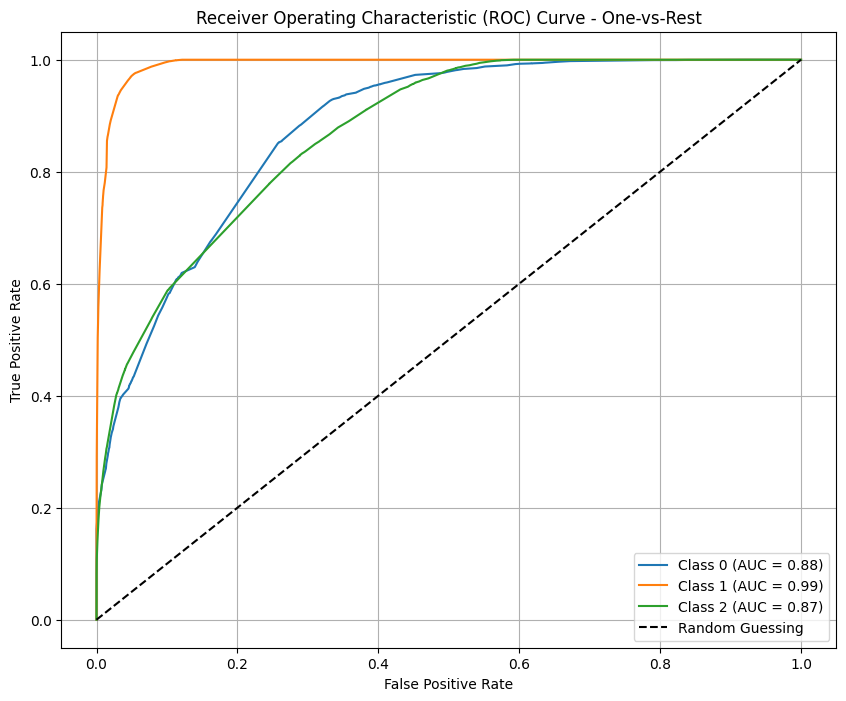

AUC for each class:
  Class 0: 0.8787
  Class 1: 0.9919
  Class 2: 0.8711


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels for ROC calculation (one-vs-rest approach)
# num_classes was already determined in a previous cell
y_test_binarized = label_binarize(y_test, classes=np.arange(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("AUC for each class:")
for i in range(num_classes):
    print(f"  Class {i}: {roc_auc[i]:.4f}")

In [ ]:
import pandas as pd

# Combine numerical and categorical features for X_train
X_train_categorical_df = pd.DataFrame(X_train_categorical_inputs)
X_train_full = pd.concat([X_train_numerical_scaled_df, X_train_categorical_df], axis=1)

# Combine numerical and categorical features for X_test
X_test_categorical_df = pd.DataFrame(X_test_categorical_inputs)
X_test_full = pd.concat([X_test_numerical_scaled_df, X_test_categorical_df], axis=1)

# Export X_train_full to CSV
X_train_full.to_csv('X_train_data.csv', index=False)
print('X_train_data.csv exported successfully.')

# Export y_train to CSV
y_train.to_csv('y_train_labels.csv', index=False)
print('y_train_labels.csv exported successfully.')

# Export X_test_full to CSV
X_test_full.to_csv('X_test_data.csv', index=False)
print('X_test_data.csv exported successfully.')

# Export y_test to CSV
y_test.to_csv('y_test_labels.csv', index=False)
print('y_test_labels.csv exported successfully.')

X_train_data.csv exported successfully.
y_train_labels.csv exported successfully.
X_test_data.csv exported successfully.
y_test_labels.csv exported successfully.
